# 06 Country Clustering

## Objective

Use unsupervised machine learning to group countries into housing affordability market profiles.

The clustering analysis uses latest-year housing affordability, valuation, price pressure, and urban growth indicators to identify countries with similar housing stress characteristics.

## Input

- `data/processed/housing_macro_with_stress_score.csv`

## Output

- Country cluster assignments
- Cluster profile summary
- Cluster visualization
- Business interpretation of housing market profiles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

PROCESSED_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete")

Setup complete


In [2]:
df = pd.read_csv(PROCESSED_DIR / "housing_macro_with_stress_score.csv")

print("Shape:", df.shape)
print("Years:", df["year"].min(), "-", df["year"].max())
print("Countries:", df["country_id"].nunique())

df.head()

Shape: (902, 27)
Years: 2000 - 2024
Countries: 40


,country_id,country_name,year,nominal_house_price_index,price_to_income_ratio,price_to_rent_ratio,real_house_price_index,rent_price_index,gdp_per_capita_constant_usd,gdp_per_capita_current_usd,...,rent_price_yoy_growth_pct,gdp_per_capita_yoy_growth_pct,house_price_income_gap,price_to_income_ratio_scaled,real_house_price_index_scaled,price_to_rent_ratio_scaled,urban_population_growth_pct_scaled,house_price_income_gap_scaled,housing_affordability_stress_score,housing_stress_category
0,AUS,Australia,2000,33.595673,67.822665,58.062251,47.961090,57.862362,45979.076565,21908.996802,...,NaN,NaN,0.629113,0.076037,0.260003,0.104041,0.456003,0.728783,23.090065,Low
1,AUS,Australia,2001,37.368512,69.777135,62.618848,51.543695,59.662722,46314.623530,19733.651010,...,3.111453,0.729782,6.740034,0.088434,0.279783,0.135394,0.483803,0.772478,25.360450,Low
2,AUS,Australia,2002,44.372389,81.271639,72.558473,59.617939,61.144035,47599.407929,20335.096019,...,2.482811,2.774036,12.890817,0.161339,0.324362,0.203785,0.479150,0.816459,30.787703,Low
3,AUS,Australia,2003,52.375657,91.792473,84.071694,68.972989,62.283510,48509.663218,23757.589847,...,1.863592,1.912325,13.779345,0.228068,0.376013,0.283004,0.479148,0.822812,36.062383,Low
4,AUS,Australia,2004,55.647000,91.233649,87.154344,72.246883,63.855978,50018.590448,30886.050095,...,2.524693,3.110570,1.636061,0.224524,0.394088,0.304215,0.465724,0.735983,35.811907,Low


In [3]:
latest_year = df["year"].max()

latest_df = df[df["year"] == latest_year].copy()

print("Latest year:", latest_year)
print("Countries in latest year:", latest_df["country_id"].nunique())

latest_df[[
    "country_id",
    "country_name",
    "year",
    "housing_affordability_stress_score",
    "housing_stress_category"
]].head()

Latest year: 2024
Countries in latest year: 37


,country_id,country_name,year,housing_affordability_stress_score,housing_stress_category
24,AUS,Australia,2024,56.426518,Moderate
49,AUT,Austria,2024,51.116006,Moderate
74,BEL,Belgium,2024,44.382319,Moderate
94,BGR,Bulgaria,2024,54.292324,Moderate
119,CAN,Canada,2024,65.080985,High


## Feature Selection

I selected indicators that represent different dimensions of housing affordability pressure:

- Overall housing stress
- Price-to-income pressure
- Price-to-rent valuation pressure
- Real house price pressure
- Urban population growth
- House-price-income gap

In [4]:
cluster_features = [
    "housing_affordability_stress_score",
    "price_to_income_ratio",
    "price_to_rent_ratio",
    "real_house_price_index",
    "urban_population_growth_pct",
    "house_price_income_gap"
]

cluster_df = latest_df[[
    "country_id",
    "country_name",
    "year"
] + cluster_features].copy()

cluster_df.head()

,country_id,country_name,year,housing_affordability_stress_score,price_to_income_ratio,price_to_rent_ratio,real_house_price_index,urban_population_growth_pct,house_price_income_gap
24,AUS,Australia,2024,56.426518,120.135414,130.408288,122.182572,2.125713,3.205547
49,AUT,Austria,2024,51.116006,114.681996,115.514314,122.587395,0.849927,-2.401998
74,BEL,Belgium,2024,44.382319,96.745664,111.753811,105.708081,0.735389,1.072386
94,BGR,Bulgaria,2024,54.292324,90.630670,160.013039,140.950754,0.214487,7.478791
119,CAN,Canada,2024,65.080985,136.187074,135.818676,144.157311,3.174276,1.974281


In [5]:
cluster_df[cluster_features].isna().sum()

housing_affordability_stress_score    0
price_to_income_ratio                 0
price_to_rent_ratio                   0
real_house_price_index                0
urban_population_growth_pct           0
house_price_income_gap                0
dtype: int64

In [6]:
for col in cluster_features:
    cluster_df[col] = cluster_df[col].fillna(cluster_df[col].median())

cluster_df[cluster_features].isna().sum()

housing_affordability_stress_score    0
price_to_income_ratio                 0
price_to_rent_ratio                   0
real_house_price_index                0
urban_population_growth_pct           0
house_price_income_gap                0
dtype: int64

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_df[cluster_features])

X_scaled[:5]

array([[ 0.43143171,  0.74071733,  0.01237796, -0.25334952,  1.71946383,
         0.65801878],
       [-0.14024836,  0.42491442, -0.67873327, -0.23613174,  0.07226511,
        -0.86102964],
       [-0.86513423, -0.61376366, -0.8532284 , -0.95403675, -0.07561875,
         0.08015892],
       [ 0.20168429, -0.96787784,  1.38609971,  0.54489216, -0.74816734,
         1.81561342],
       [ 1.36309088,  1.67025562,  0.26343118,  0.68127229,  3.07328953,
         0.32447643]])

## Choosing the Number of Clusters

I tested several values of K and used silhouette score to compare clustering quality. A higher silhouette score generally indicates better-separated clusters.

In [8]:
k_values = range(2, 8)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "k": list(k_values),
    "silhouette_score": silhouette_scores
})

silhouette_results

,k,silhouette_score
0,2,0.327650
1,3,0.269407
2,4,0.236660
3,5,0.221191
4,6,0.223247
5,7,0.215941


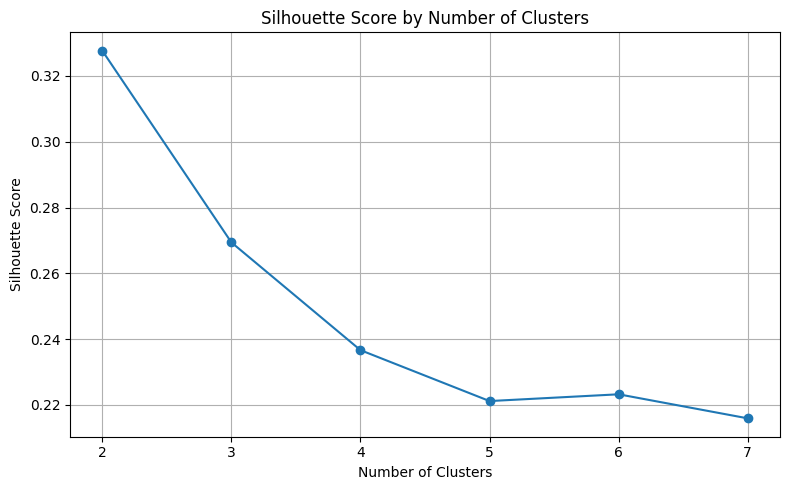

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_results["k"],
    silhouette_results["silhouette_score"],
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()

plt.savefig(IMAGES_DIR / "clustering_silhouette_scores.png", dpi=300)

plt.show()

## Final Cluster Choice

Although K=2 produced the highest silhouette score, I selected K=3 for the final clustering model because it provides more useful business interpretation.

A three-cluster solution allows the analysis to separate countries into lower-stress, moderate-stress, and high-stress housing market profiles.

In [10]:
final_k = 3

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_df[[
    "country_id",
    "country_name",
    "year",
    "cluster",
    "housing_affordability_stress_score",
    "price_to_income_ratio",
    "price_to_rent_ratio",
    "real_house_price_index",
    "urban_population_growth_pct"
]].sort_values("cluster").head(20)

,country_id,country_name,year,cluster,housing_affordability_stress_score,price_to_income_ratio,price_to_rent_ratio,real_house_price_index,urban_population_growth_pct
94,BGR,Bulgaria,2024,0,54.292324,90.630670,160.013039,140.950754,0.214487
209,CZE,Czechia,2024,0,61.611459,121.209501,158.898640,146.926102,0.458402
304,EST,Estonia,2024,0,53.815306,109.938527,133.129664,135.899243,0.179708
597,LTU,Lithuania,2024,0,58.640189,113.093238,134.816838,155.031808,0.948111
553,JPN,Japan,2024,0,51.014105,113.861527,132.584806,116.370918,-0.318996
442,HUN,Hungary,2024,0,65.532394,114.030745,165.592641,181.990760,-0.031061
424,HRV,Croatia,2024,0,57.434196,97.656391,159.284224,151.279422,0.643978
729,POL,Poland,2024,0,51.048049,101.630866,124.019024,139.593766,-0.208678
634,LVA,Latvia,2024,0,56.519188,107.521203,164.549230,138.750068,-0.754815
659,NLD,Netherlands,2024,0,65.005220,130.538403,161.189543,147.078229,0.981329


In [11]:
cluster_df["cluster"].value_counts().sort_index()

cluster
0    13
1    11
2    13
Name: count, dtype: int64

In [12]:
cluster_profile = (
    cluster_df
    .groupby("cluster")
    .agg(
        countries_count=("country_id", "count"),
        avg_stress_score=("housing_affordability_stress_score", "mean"),
        avg_price_to_income=("price_to_income_ratio", "mean"),
        avg_price_to_rent=("price_to_rent_ratio", "mean"),
        avg_real_house_price=("real_house_price_index", "mean"),
        avg_urban_growth=("urban_population_growth_pct", "mean"),
        avg_house_price_income_gap=("house_price_income_gap", "mean")
    )
    .round(2)
    .reset_index()
)

cluster_profile

,cluster,countries_count,avg_stress_score,avg_price_to_income,avg_price_to_rent,avg_real_house_price,avg_urban_growth,avg_house_price_income_gap
0,0,13,58.79,112.85,152.10,147.02,0.28,3.70
1,1,11,56.76,119.91,126.33,136.15,1.53,0.63
2,2,13,42.38,91.21,111.40,102.48,0.69,-2.03


In [13]:
cluster_name_map = {
    0: "High valuation pressure markets",
    1: "Urban growth and income pressure markets",
    2: "Lower stress / stable markets"
}

cluster_df["cluster_name"] = cluster_df["cluster"].map(cluster_name_map)

cluster_df[[
    "country_name",
    "cluster",
    "cluster_name",
    "housing_affordability_stress_score",
    "price_to_income_ratio",
    "price_to_rent_ratio",
    "real_house_price_index",
    "urban_population_growth_pct",
    "house_price_income_gap"
]].sort_values(["cluster", "housing_affordability_stress_score"], ascending=[True, False])

,country_name,cluster,cluster_name,housing_affordability_stress_score,price_to_income_ratio,price_to_rent_ratio,real_house_price_index,urban_population_growth_pct,house_price_income_gap
754,Portugal,0,High valuation pressure markets,75.350577,147.263891,173.251483,179.975719,1.296659,5.121149
442,Hungary,0,High valuation pressure markets,65.532394,114.030745,165.592641,181.990760,-0.031061,6.655638
659,Netherlands,0,High valuation pressure markets,65.005220,130.538403,161.189543,147.078229,0.981329,4.977103
209,Czechia,0,High valuation pressure markets,61.611459,121.209501,158.898640,146.926102,0.458402,0.954480
404,Greece,0,High valuation pressure markets,60.757467,116.000671,160.327457,147.632588,0.260311,4.771717
597,Lithuania,0,High valuation pressure markets,58.640189,113.093238,134.816838,155.031808,0.948111,6.144315
424,Croatia,0,High valuation pressure markets,57.434196,97.656391,159.284224,151.279422,0.643978,3.042889
634,Latvia,0,High valuation pressure markets,56.519188,107.521203,164.549230,138.750068,-0.754815,-0.179594
94,Bulgaria,0,High valuation pressure markets,54.292324,90.630670,160.013039,140.950754,0.214487,7.478791
304,Estonia,0,High valuation pressure markets,53.815306,109.938527,133.129664,135.899243,0.179708,3.004520


## Cluster Interpretation

The final K-Means model grouped countries into three housing market profiles:

### Cluster 0: High valuation pressure markets

These countries show relatively high average stress, high price-to-rent ratios, high real house price index values, and a positive house-price-income gap. This suggests housing valuation pressure and real house price growth are important drivers.

### Cluster 1: Urban growth and income pressure markets

These countries show high price-to-income ratios and higher urban population growth. This profile suggests affordability pressure may be more connected to income pressure and demographic demand context.

### Cluster 2: Lower stress / stable markets

These countries show lower average stress scores, lower price-to-income ratios, lower real house price index values, and a negative house-price-income gap. This suggests comparatively lower affordability stress in the latest year.

In [14]:
pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(X_scaled)

cluster_df["pca_1"] = pca_components[:, 0]
cluster_df["pca_2"] = pca_components[:, 1]

cluster_df[[
    "country_name",
    "cluster_name",
    "pca_1",
    "pca_2"
]].head()

,country_name,cluster_name,pca_1,pca_2
24,Australia,Urban growth and income pressure markets,0.832541,1.571189
49,Austria,Urban growth and income pressure markets,-0.586762,0.664912
74,Belgium,Lower stress / stable markets,-1.513242,-0.004018
94,Bulgaria,High valuation pressure markets,1.100352,-1.921877
119,Canada,Urban growth and income pressure markets,2.294091,3.007834


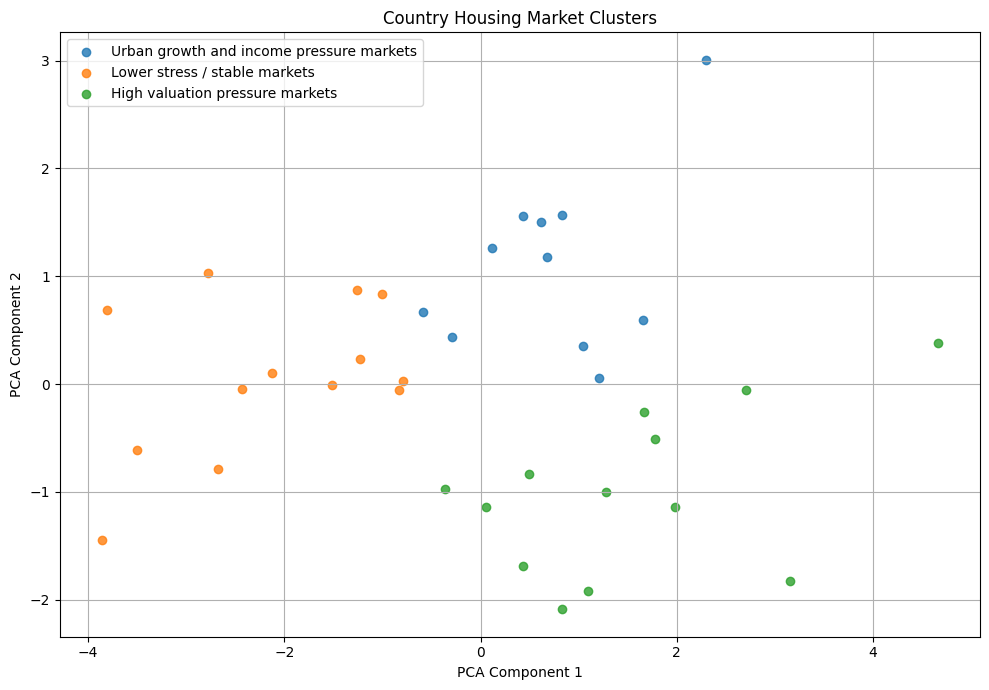

In [15]:
plt.figure(figsize=(10, 7))

for cluster_name in cluster_df["cluster_name"].unique():
    subset = cluster_df[cluster_df["cluster_name"] == cluster_name]

    plt.scatter(
        subset["pca_1"],
        subset["pca_2"],
        label=cluster_name,
        alpha=0.8
    )

plt.title("Country Housing Market Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(IMAGES_DIR / "country_housing_market_clusters.png", dpi=300)

plt.show()

In [16]:
cluster_output = cluster_df[[
    "country_id",
    "country_name",
    "year",
    "cluster",
    "cluster_name",
    "housing_affordability_stress_score",
    "price_to_income_ratio",
    "price_to_rent_ratio",
    "real_house_price_index",
    "urban_population_growth_pct",
    "house_price_income_gap"
]].copy()

cluster_output.to_csv(
    PROCESSED_DIR / "country_housing_clusters.csv",
    index=False
)

print("Saved cluster assignments to:")
print(PROCESSED_DIR / "country_housing_clusters.csv")

Saved cluster assignments to:
..\data\processed\country_housing_clusters.csv


## Clustering Summary

The clustering analysis adds an unsupervised machine learning layer to the project. Instead of only ranking countries by stress score, the model groups countries with similar housing affordability characteristics.

This helps turn the analysis from simple ranking into market segmentation.

The three final cluster profiles are:

1. High valuation pressure markets
2. Urban growth and income pressure markets
3. Lower stress / stable markets